#LangGraph Quickstart Example (Version 1.0)

This notebook is an almost literal copy of LangChain's LangGraph Quickstart. Minor edits and extensions were made for readability and instructional purposes.


Core source:
https://docs.langchain.com/oss/python/langgraph/quickstart#full-code-example

This simple Agent will be driven by a language model that, presented with a question, can decide to iteratively use tools to generate an answer.  This notebook uses an Open AI LLM via API calls so you need to have an OpenAI API key to run it.


We have three nodes:

 * The **LLM Node** that decides whether to use tools and with what arguments, and generates the answer once all information is available
 * A **Tool Node** that executes the tool calls and adds the results to the message stream
 * A **Result Node** - added here relative to the source purely for illustration purposes - that extracts the result and prints it.

Our simple test questions to test will be:

 * Add 3 and 4
 * Add 2 and 6 and then divide the result by 4
 * Add 2 and 6 and then divide the result by 4, then add 3 and multiply by 3

Let us see whether this simple agent can complete the tasks. Specifically, you may want to see i) whether the correct tools are called, ii) with the proper arguments, and iii) whether the answer is correct.

##0. Setup

We first need to set up the environment.

In [1]:
%%capture
!pip install langgraph
!pip install langchain
!pip install -U langchain-openai

In [2]:
import os
from google.colab import userdata

from langchain.tools import tool
from langchain.chat_models import init_chat_model

from langchain_core.messages import AnyMessage       # delta to Quickstart
from typing_extensions import TypedDict, Annotated
import operator

from langchain_core.messages import SystemMessage       # delta to Quickstart
from langchain_core.messages import ToolMessage

from typing import Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage       # delta to Quickstart


In [3]:
#load the API key
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

##1. Prep Work - Tools & Model

We start by defining the tools and the model that we want to use.  These are all functions we'll call from within our graph.

In [4]:
#Define the model
model = init_chat_model(
    "openai:gpt-4.1",
    temperature=0,

)


# Define three tools -- one for multiply, one for add, and one for divide
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)



A [graph](https://langchain-ai.github.io/langgraph/concepts/low_level/#graphs) consists of three components:  

1. **States**

    This is usually a data structure that represents the current state of the graph.  In our case we'll use a Dict.

2. **Nodes**

    Nodes are functions that accomplish things.  They can take the current state of the graph, perform appropraite computations, and return a revised state.  We'll define three -- an llm node, a tool call node, and a results node.

3. **Edges**

    Edges define the node(s) to run based on the current state of the graph.

###Step 1: Define the State

In [5]:
# minor modification for illustration purposes. Added a 'result' state variable
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int
    result: None

###Step 2: Define the Nodes

####Step 2a: Build the Main Node

In [6]:
def llm_call(state: dict):
    """This is the orchestration node for this simple agent. The
    LLM decides whether to call a tool or not"""

    # Read State variables as needed for use in the node
    num_tool_calls = state.get('llm_calls', 0)
    messages_so_far = state["messages"]

    # Some logging as desired
    print(f"Executing orchestration node with {len(messages_so_far)} messages in history")

    # Do the work
    llm_invocation = model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + messages_so_far
            )

    # Update the state variables and leave the node
    return {
        "messages": [llm_invocation],      # ADD llm invocation result to messages
        "llm_calls":  num_tool_calls + 1   # update number of tool calls
    }



####Step 2b: Build the Tool Node

In [7]:
def tool_node(state: dict):
    """Performs the tool call"""

    # Read State variables as needed for use in the node
    tool_calls = state["messages"][-1].tool_calls

    # Some logging as desired
    print(f"Executing tool node for {len(tool_calls)} tool calls")

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool = tools_by_name[tool_name]
        print(f"\tCalling tool: {tool_name} with arguments {str(tool_args)}")
        observation = tool.invoke(tool_args)
        print(f"\t\tResult: {observation}")
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}



####Step 2c: Build a Result Node
Note: This has been added relative to the Quickstart

In [8]:
def result_node(state: dict):
    """This node has been added for illustration purposes.
    All that it is doing is printing out the final result."""

    # Read State variables as needed for use in the node
    last_message = state["messages"][-1]


    # Extract the result
    result = last_message.content

    #Print the result
    print(f"The result is:\n {result}")

    #Update the state variables and leave the node
    return {
        "result": result
    }

###Step 3: Build the Conditional Edges (the Logic)

In [9]:
# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", "result_node"]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    # Get what you need from the State
    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return "result_node"



###Step 4: Putting the Agent Together - Building the Graph

Now we assemble the nodes and edges and then compile the graph so we can invoke it.

In [10]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes (2 nodes in this case)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("result_node", result_node)


# Add edges to connect nodes
# Edges can be fixed or conditional
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", "result_node"]
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("result_node", END)


# Compile the agent
agent = agent_builder.compile()

##3. Visualize the Graph

It is often helpful to see a visual representation of the graph we have created to see if it actually corrresponds to the graph we think we have created.

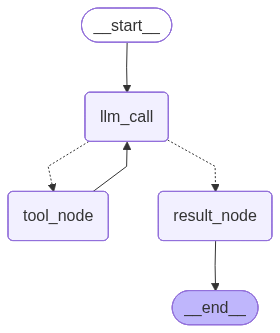

In [11]:
from IPython.display import Image, display
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



##4. Run It!

###4.1 Simple Addition

In [12]:
# Define your message
messages = [HumanMessage(content="Add 3 and 4.")]

# Invoke the graph
messages = agent.invoke({"messages": messages})

#for m in messages["messages"]:
#    m.pretty_print()

Executing orchestration node with 1 messages in history
Executing tool node for 1 tool calls
	Calling tool: add with arguments {'a': 3, 'b': 4}
		Result: 7
Executing orchestration node with 3 messages in history
The result is:
 3 plus 4 equals 7.


In [13]:
messages['messages'][-1]

AIMessage(content='3 plus 4 equals 7.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 187, 'total_tokens': 196, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_06d6f3a26a', 'id': 'chatcmpl-DxhCGH2FeWGpjUTrKf5vmvwVJcEdD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f2a38-7a46-71d3-98cf-ca99404b3c53-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 9, 'total_tokens': 196, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})


###4.2 Simple Addition Followed by Division

In [14]:
messages = agent.invoke({"messages": [HumanMessage(content="Add 2 and 6 and then divide the result by 4")]})

Executing orchestration node with 1 messages in history
Executing tool node for 1 tool calls
	Calling tool: add with arguments {'a': 2, 'b': 6}
		Result: 8
Executing orchestration node with 3 messages in history
Executing tool node for 1 tool calls
	Calling tool: divide with arguments {'a': 8, 'b': 4}
		Result: 2.0
Executing orchestration node with 5 messages in history
The result is:
 First, 2 and 6 are added to get 8. Then, 8 is divided by 4 to get 2. The final result is 2.


###4.2 Adding a few More Steps

In [15]:
messages = agent.invoke({"messages": [HumanMessage(content="Add 2 and 6 and then divide the result by 4. Then add 3 and multiply by 3")]})

Executing orchestration node with 1 messages in history
Executing tool node for 1 tool calls
	Calling tool: add with arguments {'a': 2, 'b': 6}
		Result: 8
Executing orchestration node with 3 messages in history
Executing tool node for 1 tool calls
	Calling tool: divide with arguments {'a': 8, 'b': 4}
		Result: 2.0
Executing orchestration node with 5 messages in history
Executing tool node for 1 tool calls
	Calling tool: add with arguments {'a': 2, 'b': 3}
		Result: 5
Executing orchestration node with 7 messages in history
Executing tool node for 1 tool calls
	Calling tool: multiply with arguments {'a': 5, 'b': 3}
		Result: 15
Executing orchestration node with 9 messages in history
The result is:
 Here are the steps and results for your request:
1. Add 2 and 6: 2 + 6 = 8
2. Divide the result by 4: 8 ÷ 4 = 2
3. Add 3: 2 + 3 = 5
4. Multiply by 3: 5 × 3 = 15

The final result is 15.


All looks good!

Finally, let us look at some components of the message history for the last invocation:

In [16]:
messages['messages'][-3].tool_calls

[{'name': 'multiply',
  'args': {'a': 5, 'b': 3},
  'id': 'call_XyrFYk7x88ThWcvbywwZDmTj',
  'type': 'tool_call'}]

In [17]:
messages['messages'][-2]

ToolMessage(content='15', tool_call_id='call_XyrFYk7x88ThWcvbywwZDmTj')

Great. We see the last tool call and its result.